# Essentials of Statistics with Python

# **A Complete Guide to Statistical Analysis Using Python**

This tutorial covers:
1. Descriptive Statistics
2. Probability Distributions
3. Sampling and Estimation
4. Hypothesis Testing
5. Correlation and Regression
6. ANOVA (Analysis of Variance)
7. Non-parametric Statistics
8. Bayesian Statistics
9. Time Series Analysis
10. Practical Case Studies

## 1. Setup and Required Libraries

In [5]:
# Import essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, t, f, chi2, binom, poisson, uniform
from scipy.stats import ttest_ind, ttest_rel, ttest_1samp
from scipy.stats import pearsonr, spearmanr, kendalltau
from scipy.stats import f_oneway, kruskal, mannwhitneyu
import statsmodels.api as sm
from statsmodels.formula.api import ols
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Libraries imported successfully!
NumPy version: 1.26.2
Pandas version: 2.2.3


## 2. Descriptive Statistics

In [8]:
# Create sample dataset
np.random.seed(42)
data = {
    'Age': np.random.normal(35, 10, 500),
    'Income': np.random.normal(50000, 15000, 500),
    'Score': np.random.uniform(0, 100, 500),
    'Category': np.random.choice(['A', 'B', 'C', 'D'], 500)
}

df = pd.DataFrame(data)
print("Dataset Preview:")
print(df.head(10))

Dataset Preview:
      Age     Income   Score Category
0 39.9671 63892.6632 16.7483        C
1 33.6174 78641.2496 10.4568        A
2 41.4769 29021.4864 63.6430        A
3 50.2303 58444.5386 70.6476        C
4 32.6585 40240.3615  3.1586        D
5 32.6586 42693.1192 93.6212        C
6 50.7921 41114.0911  5.1971        D
7 42.6743 37040.1385 54.1296        A
8 30.3053 50727.8244 70.9061        A
9 40.4256 37535.7483 87.0969        D


In [10]:
# Measures of Central Tendency
print("=" * 50)
print("MEASURES OF CENTRAL TENDENCY")
print("=" * 50)
print(f"Mean Age: {df['Age'].mean():.2f}")
print(f"Median Age: {df['Age'].median():.2f}")
print(f"Mode Age: {df['Age'].mode().iloc[0] if len(df['Age'].mode()) > 0 else 'No unique mode':.2f}")
print(f"\nMean Income: ${df['Income'].mean():.2f}")
print(f"Median Income: ${df['Income'].median():.2f}")

MEASURES OF CENTRAL TENDENCY
Mean Age: 35.07
Median Age: 35.13
Mode Age: 2.59

Mean Income: $50477.39
Median Income: $50427.97


In [12]:
# Measures of Dispersion
print("=" * 50)
print("MEASURES OF DISPERSION")
print("=" * 50)
print(f"Range of Age: {df['Age'].max() - df['Age'].min():.2f}")
print(f"Variance of Age: {df['Age'].var():.2f}")
print(f"Standard Deviation of Age: {df['Age'].std():.2f}")
print(f"Interquartile Range (IQR) of Age: {df['Age'].quantile(0.75) - df['Age'].quantile(0.25):.2f}")
print(f"Coefficient of Variation (Age): {(df['Age'].std() / df['Age'].mean()) * 100:.2f}%")

MEASURES OF DISPERSION
Range of Age: 70.94
Variance of Age: 96.29
Standard Deviation of Age: 9.81
Interquartile Range (IQR) of Age: 13.37
Coefficient of Variation (Age): 27.98%


In [14]:
# Shape Statistics
print("=" * 50)
print("SHAPE STATISTICS")
print("=" * 50)
print(f"Skewness of Income: {df['Income'].skew():.3f}")
print(f"Kurtosis of Income: {df['Income'].kurtosis():.3f}")

# Interpretation guide
print("\nInterpretation:")
print("- Skewness: Negative = left-skewed, 0 = symmetric, Positive = right-skewed")
print("- Kurtosis: Negative = platykurtic (light tails), Positive = leptokurtic (heavy tails)")

SHAPE STATISTICS
Skewness of Income: 0.054
Kurtosis of Income: -0.109

Interpretation:
- Skewness: Negative = left-skewed, 0 = symmetric, Positive = right-skewed
- Kurtosis: Negative = platykurtic (light tails), Positive = leptokurtic (heavy tails)


In [16]:
# Comprehensive statistical summary
print("=" * 50)
print("COMPREHENSIVE STATISTICAL SUMMARY")
print("=" * 50)
print(df.describe())

COMPREHENSIVE STATISTICAL SUMMARY
           Age     Income    Score
count 500.0000   500.0000 500.0000
mean   35.0684 50477.3918  50.2180
std     9.8125 14669.9579  28.9609
min     2.5873  9546.7004   0.4940
25%    27.9969 41070.6239  23.8771
50%    35.1280 50427.9740  51.0822
75%    41.3678 59768.6345  73.6520
max    73.5273 89485.7310  99.9414


## 3. Data Visualization for Statistics

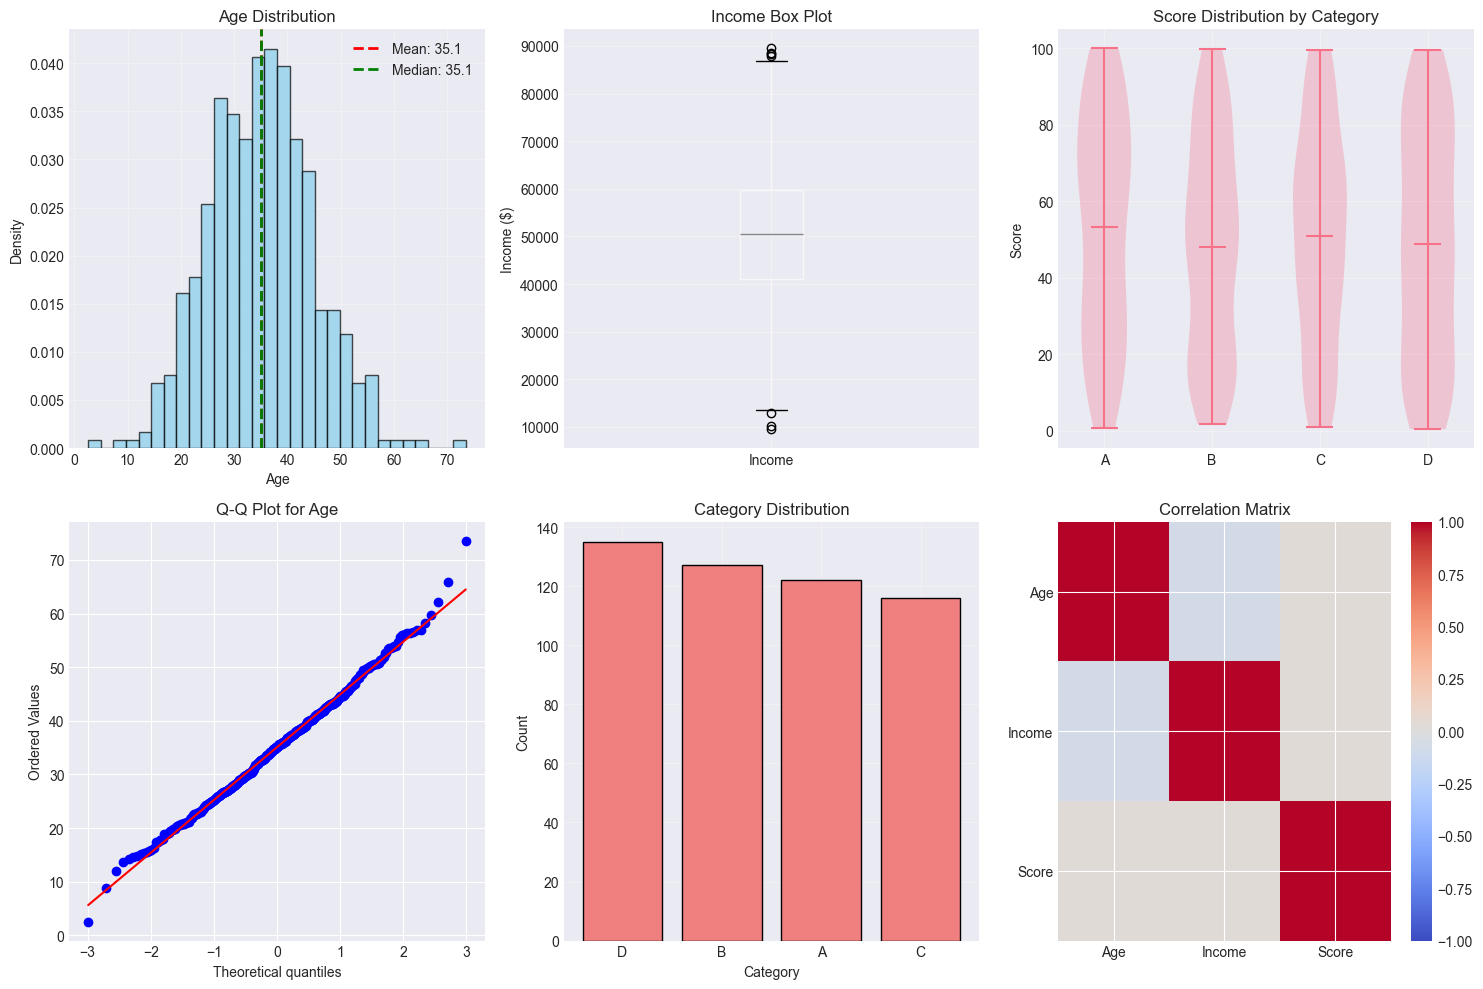

In [19]:
# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Histogram with KDE
axes[0,0].hist(df['Age'], bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Age"].mean():.1f}')
axes[0,0].axvline(df['Age'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["Age"].median():.1f}')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Density')
axes[0,0].set_title('Age Distribution')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Box plot
df.boxplot(column='Income', ax=axes[0,1])
axes[0,1].set_title('Income Box Plot')
axes[0,1].set_ylabel('Income ($)')
axes[0,1].grid(True, alpha=0.3)

# 3. Violin plot
parts = axes[0,2].violinplot([df[df['Category'] == cat]['Score'] for cat in ['A', 'B', 'C', 'D']], 
                              positions=[1,2,3,4], showmeans=True)
axes[0,2].set_xticks([1,2,3,4])
axes[0,2].set_xticklabels(['A', 'B', 'C', 'D'])
axes[0,2].set_title('Score Distribution by Category')
axes[0,2].set_ylabel('Score')
axes[0,2].grid(True, alpha=0.3)

# 4. Q-Q plot (Normality check)
stats.probplot(df['Age'], dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot for Age')

# 5. Bar plot of categorical data
category_counts = df['Category'].value_counts()
axes[1,1].bar(category_counts.index, category_counts.values, color='lightcoral', edgecolor='black')
axes[1,1].set_title('Category Distribution')
axes[1,1].set_xlabel('Category')
axes[1,1].set_ylabel('Count')
axes[1,1].grid(True, alpha=0.3)

# 6. Correlation heatmap
corr_matrix = df[['Age', 'Income', 'Score']].corr()
im = axes[1,2].imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
axes[1,2].set_xticks(range(len(corr_matrix.columns)))
axes[1,2].set_yticks(range(len(corr_matrix.columns)))
axes[1,2].set_xticklabels(corr_matrix.columns)
axes[1,2].set_yticklabels(corr_matrix.columns)
axes[1,2].set_title('Correlation Matrix')
plt.colorbar(im, ax=axes[1,2])

plt.tight_layout()
plt.show()

## 4. Probability Distributions

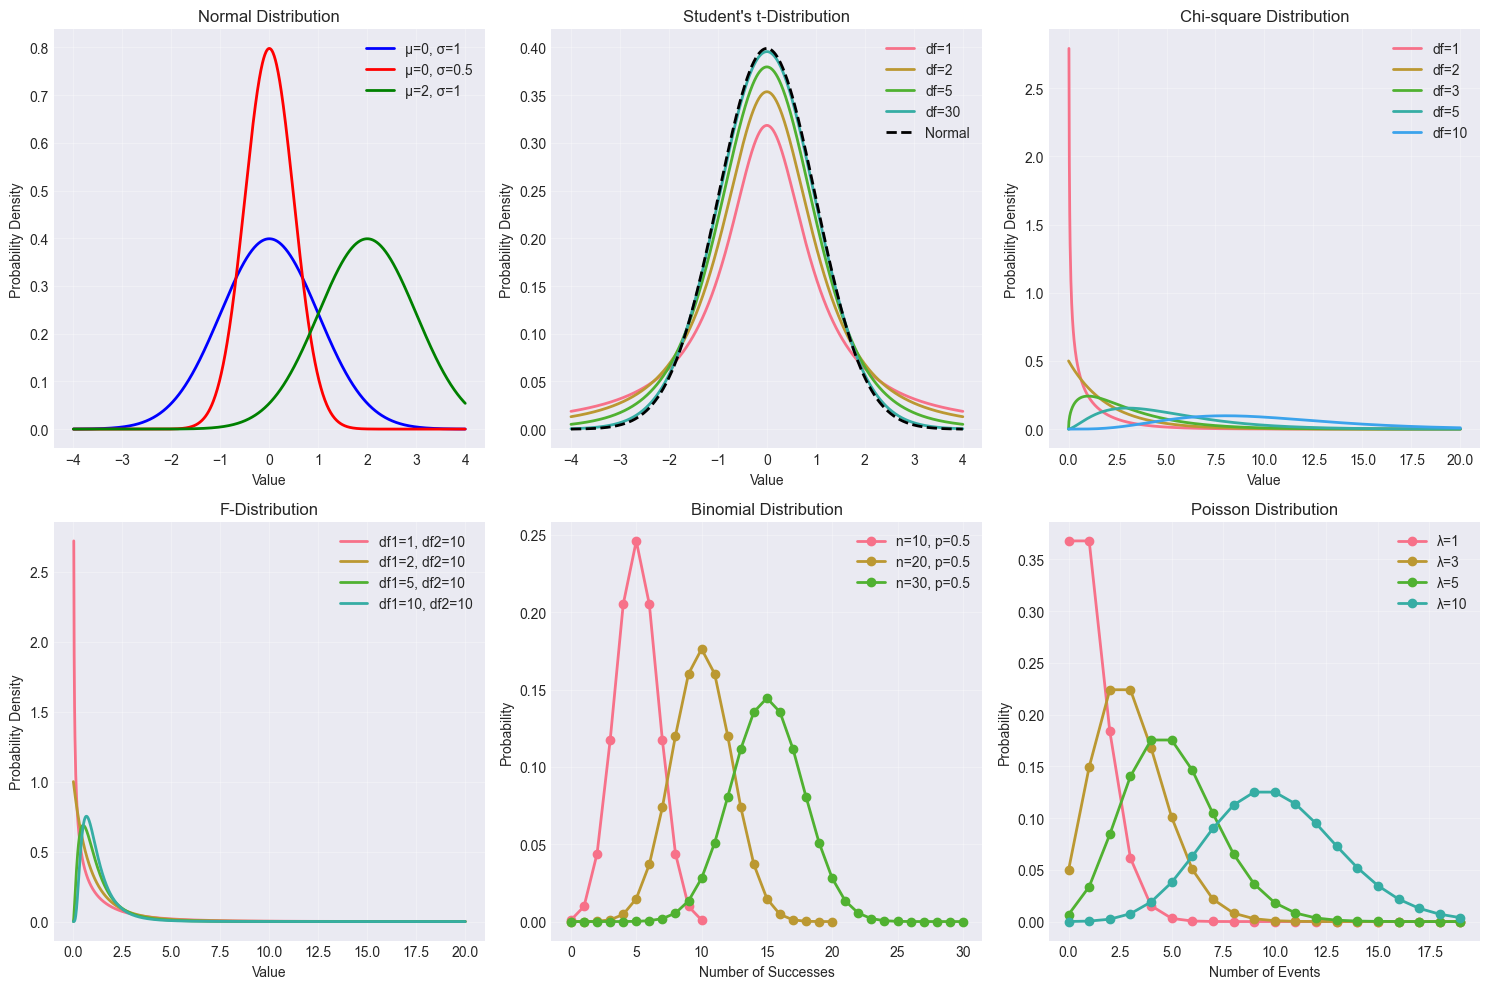

In [22]:
# Generate different probability distributions
np.random.seed(42)
x = np.linspace(-4, 4, 1000)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Normal (Gaussian) Distribution
axes[0,0].plot(x, norm.pdf(x, 0, 1), 'b-', linewidth=2, label='μ=0, σ=1')
axes[0,0].plot(x, norm.pdf(x, 0, 0.5), 'r-', linewidth=2, label='μ=0, σ=0.5')
axes[0,0].plot(x, norm.pdf(x, 2, 1), 'g-', linewidth=2, label='μ=2, σ=1')
axes[0,0].set_title('Normal Distribution')
axes[0,0].set_xlabel('Value')
axes[0,0].set_ylabel('Probability Density')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Student's t-distribution
df_values = [1, 2, 5, 30]
for df_val in df_values:
    axes[0,1].plot(x, t.pdf(x, df_val), linewidth=2, label=f'df={df_val}')
axes[0,1].plot(x, norm.pdf(x, 0, 1), 'k--', linewidth=2, label='Normal')
axes[0,1].set_title("Student's t-Distribution")
axes[0,1].set_xlabel('Value')
axes[0,1].set_ylabel('Probability Density')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Chi-square Distribution
df_values = [1, 2, 3, 5, 10]
x_chi2 = np.linspace(0, 20, 1000)
for df_val in df_values:
    axes[0,2].plot(x_chi2, chi2.pdf(x_chi2, df_val), linewidth=2, label=f'df={df_val}')
axes[0,2].set_title('Chi-square Distribution')
axes[0,2].set_xlabel('Value')
axes[0,2].set_ylabel('Probability Density')
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# 4. F-distribution
dfn_values = [1, 2, 5, 10]
for dfn in dfn_values:
    axes[1,0].plot(x_chi2, f.pdf(x_chi2, dfn, 10), linewidth=2, label=f'df1={dfn}, df2=10')
axes[1,0].set_title('F-Distribution')
axes[1,0].set_xlabel('Value')
axes[1,0].set_ylabel('Probability Density')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 5. Binomial Distribution
n_trials = [10, 20, 30]
p = 0.5
for n in n_trials:
    x_binom = np.arange(0, n+1)
    axes[1,1].plot(x_binom, binom.pmf(x_binom, n, p), 'o-', linewidth=2, label=f'n={n}, p={p}')
axes[1,1].set_title('Binomial Distribution')
axes[1,1].set_xlabel('Number of Successes')
axes[1,1].set_ylabel('Probability')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

# 6. Poisson Distribution
lambda_values = [1, 3, 5, 10]
x_pois = np.arange(0, 20)
for lam in lambda_values:
    axes[1,2].plot(x_pois, poisson.pmf(x_pois, lam), 'o-', linewidth=2, label=f'λ={lam}')
axes[1,2].set_title('Poisson Distribution')
axes[1,2].set_xlabel('Number of Events')
axes[1,2].set_ylabel('Probability')
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Sampling and Central Limit Theorem

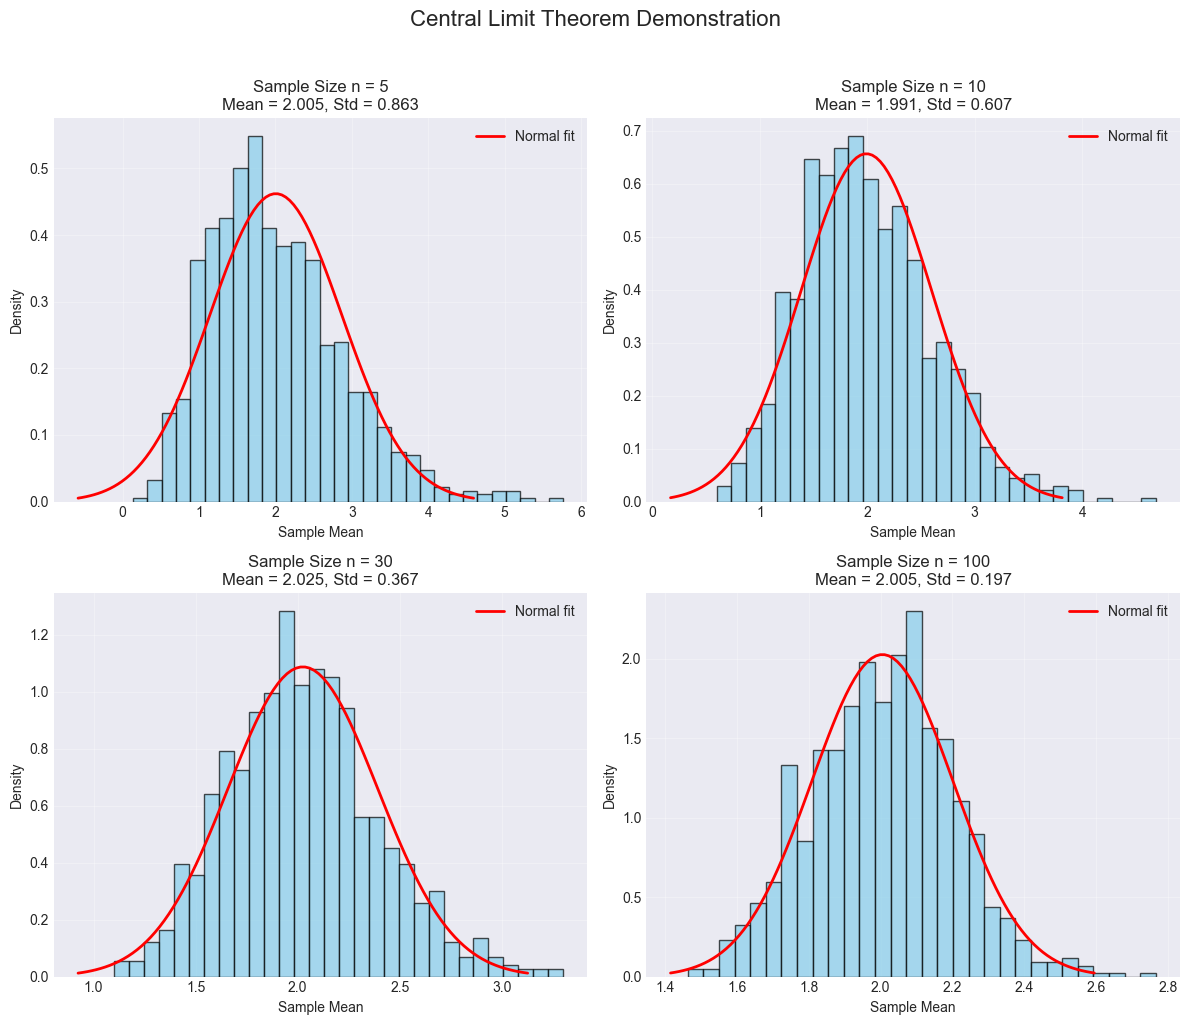

Population Statistics (Exponential Distribution):
Population Mean: 1.992
Population Std: 1.986

As sample size increases, the sampling distribution becomes more normal and the standard error decreases!


In [25]:
# Demonstrate Central Limit Theorem
np.random.seed(42)

# Create a non-normal population (exponential distribution)
population = np.random.exponential(scale=2, size=100000)

# Draw samples of different sizes
sample_sizes = [5, 10, 30, 100]
num_samples = 1000

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, sample_size in enumerate(sample_sizes):
    # Calculate sample means
    sample_means = [np.mean(np.random.choice(population, size=sample_size, replace=True)) 
                    for _ in range(num_samples)]
    
    # Plot histogram of sample means
    axes[idx].hist(sample_means, bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black')
    
    # Overlay normal distribution
    mu = np.mean(sample_means)
    sigma = np.std(sample_means)
    x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
    axes[idx].plot(x, norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal fit')
    
    axes[idx].set_title(f'Sample Size n = {sample_size}\nMean = {mu:.3f}, Std = {sigma:.3f}')
    axes[idx].set_xlabel('Sample Mean')
    axes[idx].set_ylabel('Density')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Central Limit Theorem Demonstration', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Population statistics
print("Population Statistics (Exponential Distribution):")
print(f"Population Mean: {np.mean(population):.3f}")
print(f"Population Std: {np.std(population):.3f}")
print("\nAs sample size increases, the sampling distribution becomes more normal and the standard error decreases!")

# 6. Confidence Intervals

CONFIDENCE INTERVALS

90% Confidence Interval:
Sample Mean: 98.44
Margin of Error: 2.26
Confidence Interval: (96.18, 100.70)

95% Confidence Interval:
Sample Mean: 98.44
Margin of Error: 2.70
Confidence Interval: (95.74, 101.15)

99% Confidence Interval:
Sample Mean: 98.44
Margin of Error: 3.58
Confidence Interval: (94.86, 102.02)


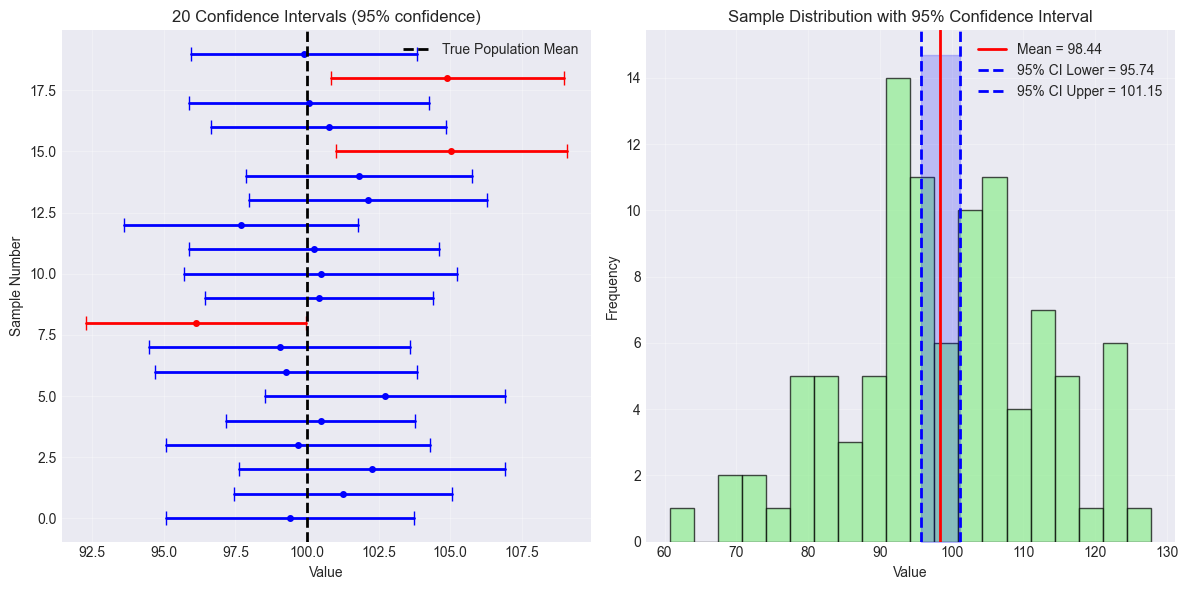

In [28]:
def calculate_confidence_interval(data, confidence=0.95):
    """Calculate confidence interval for a given dataset"""
    n = len(data)
    mean = np.mean(data)
    se = stats.sem(data)  # Standard error of the mean
    margin = se * stats.t.ppf((1 + confidence) / 2, n - 1)
    return mean - margin, mean + margin, mean, margin

# Generate sample data
np.random.seed(42)
sample_data = np.random.normal(100, 15, 100)

# Calculate confidence intervals for different confidence levels
confidence_levels = [0.90, 0.95, 0.99]

print("=" * 60)
print("CONFIDENCE INTERVALS")
print("=" * 60)

for cl in confidence_levels:
    ci_lower, ci_upper, mean, margin = calculate_confidence_interval(sample_data, cl)
    print(f"\n{cl*100:.0f}% Confidence Interval:")
    print(f"Sample Mean: {mean:.2f}")
    print(f"Margin of Error: {margin:.2f}")
    print(f"Confidence Interval: ({ci_lower:.2f}, {ci_upper:.2f})")

# Visualization
plt.figure(figsize=(12, 6))

# Multiple samples visualization
n_intervals = 20
plt.subplot(1, 2, 1)
for i in range(n_intervals):
    sample = np.random.normal(100, 15, 50)
    ci_lower, ci_upper, mean, _ = calculate_confidence_interval(sample, 0.95)
    color = 'blue' if ci_lower <= 100 <= ci_upper else 'red'
    plt.plot([ci_lower, ci_upper], [i, i], color=color, linewidth=2, marker='|', markersize=10)
    plt.plot(mean, i, 'o', color=color, markersize=4)

plt.axvline(x=100, color='black', linestyle='--', linewidth=2, label='True Population Mean')
plt.xlabel('Value')
plt.ylabel('Sample Number')
plt.title(f'{n_intervals} Confidence Intervals (95% confidence)')
plt.legend()
plt.grid(True, alpha=0.3)

# Single sample detailed view
plt.subplot(1, 2, 2)
plt.hist(sample_data, bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
ci_lower, ci_upper, mean, margin = calculate_confidence_interval(sample_data, 0.95)
plt.axvline(mean, color='red', linestyle='-', linewidth=2, label=f'Mean = {mean:.2f}')
plt.axvline(ci_lower, color='blue', linestyle='--', linewidth=2, label=f'95% CI Lower = {ci_lower:.2f}')
plt.axvline(ci_upper, color='blue', linestyle='--', linewidth=2, label=f'95% CI Upper = {ci_upper:.2f}')
plt.fill_betweenx([0, plt.ylim()[1]], ci_lower, ci_upper, alpha=0.2, color='blue')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Sample Distribution with 95% Confidence Interval')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 7. Hypothesis Testing

ONE-SAMPLE T-TEST

Null Hypothesis (H₀): Population mean = 100
Alternative Hypothesis (H₁): Population mean ≠ 100

Case 1: Sample from population with mean = 100
Sample Mean: 96.62
t-statistic: -1.7076
p-value: 0.0940
Reject H₀ at α=0.05: False

Case 2: Sample from population with mean = 105
Sample Mean: 105.27
t-statistic: 2.8396
p-value: 0.0066
Reject H₀ at α=0.05: True


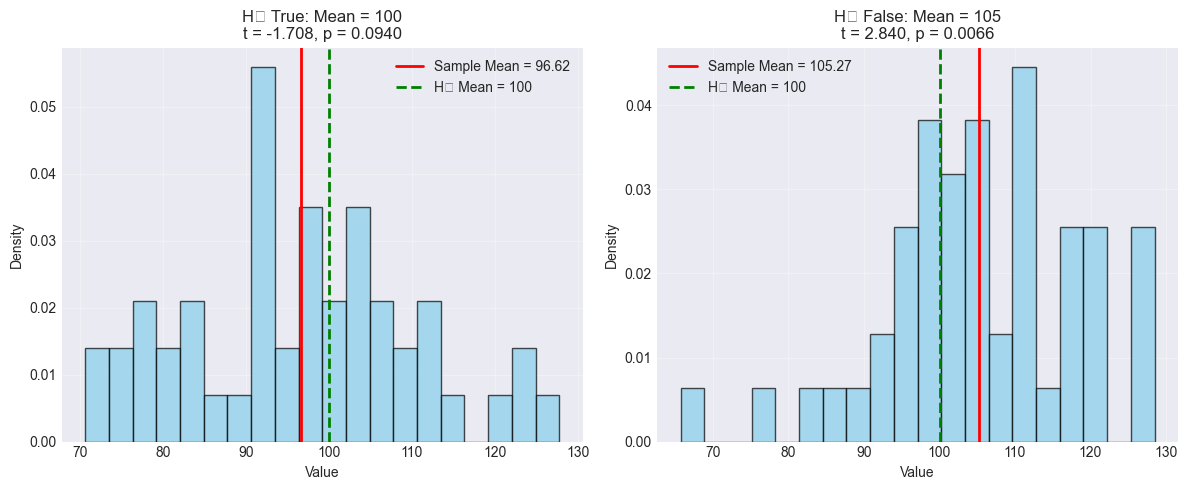

In [31]:
# One-sample t-test
np.random.seed(42)

# Generate data from two different populations
population_mean = 100
sample_size = 50

# Sample from population with mean = 100 (null hypothesis true)
sample_h0_true = np.random.normal(population_mean, 15, sample_size)

# Sample from population with mean = 105 (null hypothesis false)
sample_h0_false = np.random.normal(105, 15, sample_size)

# Perform one-sample t-tests
t_stat1, p_value1 = ttest_1samp(sample_h0_true, population_mean)
t_stat2, p_value2 = ttest_1samp(sample_h0_false, population_mean)

print("=" * 60)
print("ONE-SAMPLE T-TEST")
print("=" * 60)
print("\nNull Hypothesis (H₀): Population mean = 100")
print("Alternative Hypothesis (H₁): Population mean ≠ 100\n")

print("Case 1: Sample from population with mean = 100")
print(f"Sample Mean: {np.mean(sample_h0_true):.2f}")
print(f"t-statistic: {t_stat1:.4f}")
print(f"p-value: {p_value1:.4f}")
print(f"Reject H₀ at α=0.05: {p_value1 < 0.05}")

print("\nCase 2: Sample from population with mean = 105")
print(f"Sample Mean: {np.mean(sample_h0_false):.2f}")
print(f"t-statistic: {t_stat2:.4f}")
print(f"p-value: {p_value2:.4f}")
print(f"Reject H₀ at α=0.05: {p_value2 < 0.05}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, (sample, title, t_stat, p_val) in enumerate([
    (sample_h0_true, "H₀ True: Mean = 100", t_stat1, p_value1),
    (sample_h0_false, "H₀ False: Mean = 105", t_stat2, p_value2)
]):
    axes[idx].hist(sample, bins=20, alpha=0.7, color='skyblue', edgecolor='black', density=True)
    axes[idx].axvline(np.mean(sample), color='red', linewidth=2, label=f'Sample Mean = {np.mean(sample):.2f}')
    axes[idx].axvline(population_mean, color='green', linestyle='--', linewidth=2, label='H₀ Mean = 100')
    axes[idx].set_title(f'{title}\nt = {t_stat:.3f}, p = {p_val:.4f}')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Density')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 8. Two-Sample T-Test and Mann-Whitney U Test

TWO-SAMPLE COMPARISON

Group 1: Mean = 98.44, Std = 13.55
Group 2: Mean = 108.33, Std = 14.23
Difference in means: 9.89

Parametric Test (Independent t-test):
t-statistic: -5.0078
p-value: 0.0000
Significant difference: True

Non-parametric Test (Mann-Whitney U):
U-statistic: 3195.0
p-value: 0.0000
Significant difference: True


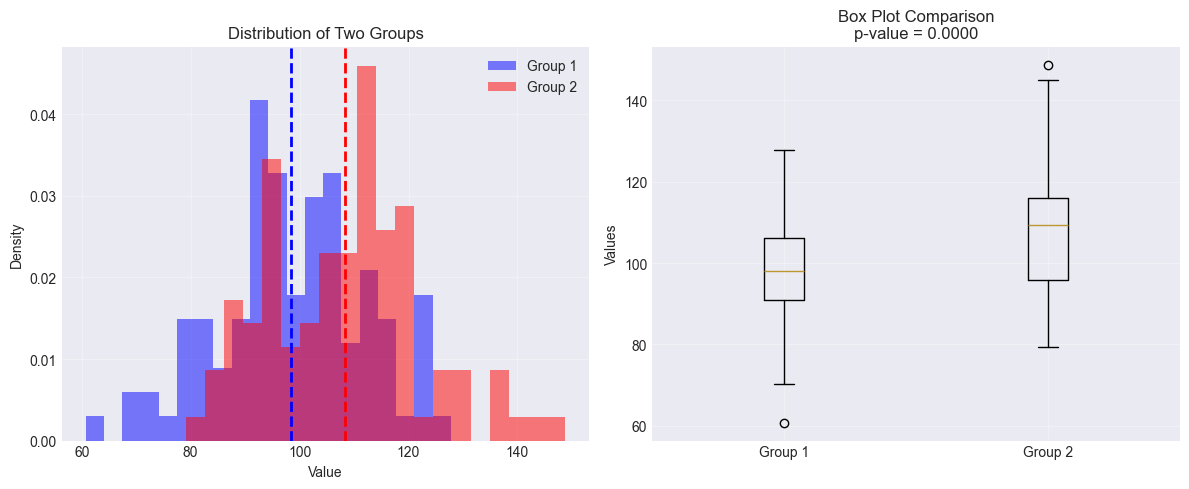

In [34]:
# Generate two independent samples
np.random.seed(42)
group1 = np.random.normal(100, 15, 100)
group2 = np.random.normal(108, 15, 100)  # Different mean

# Parametric test: Independent t-test
t_stat, p_value_t = ttest_ind(group1, group2)

# Non-parametric test: Mann-Whitney U test
u_stat, p_value_u = mannwhitneyu(group1, group2, alternative='two-sided')

print("=" * 60)
print("TWO-SAMPLE COMPARISON")
print("=" * 60)
print(f"\nGroup 1: Mean = {np.mean(group1):.2f}, Std = {np.std(group1):.2f}")
print(f"Group 2: Mean = {np.mean(group2):.2f}, Std = {np.std(group2):.2f}")
print(f"Difference in means: {np.mean(group2) - np.mean(group1):.2f}")

print("\nParametric Test (Independent t-test):")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value_t:.4f}")
print(f"Significant difference: {p_value_t < 0.05}")

print("\nNon-parametric Test (Mann-Whitney U):")
print(f"U-statistic: {u_stat:.1f}")
print(f"p-value: {p_value_u:.4f}")
print(f"Significant difference: {p_value_u < 0.05}")

# Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(group1, bins=20, alpha=0.5, label='Group 1', color='blue', density=True)
plt.hist(group2, bins=20, alpha=0.5, label='Group 2', color='red', density=True)
plt.axvline(np.mean(group1), color='blue', linestyle='--', linewidth=2)
plt.axvline(np.mean(group2), color='red', linestyle='--', linewidth=2)
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Distribution of Two Groups')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot([group1, group2], labels=['Group 1', 'Group 2'])
plt.ylabel('Values')
plt.title(f'Box Plot Comparison\np-value = {p_value_t:.4f}')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 9. Paired T-Test (Before/After)

PAIRED T-TEST (BEFORE-AFTER COMPARISON)
Before: Mean = 97.18, Std = 13.27
After: Mean = 101.81, Std = 13.82
Mean difference: 4.64

t-statistic: -9.0915
p-value: 0.0000
Significant improvement: True


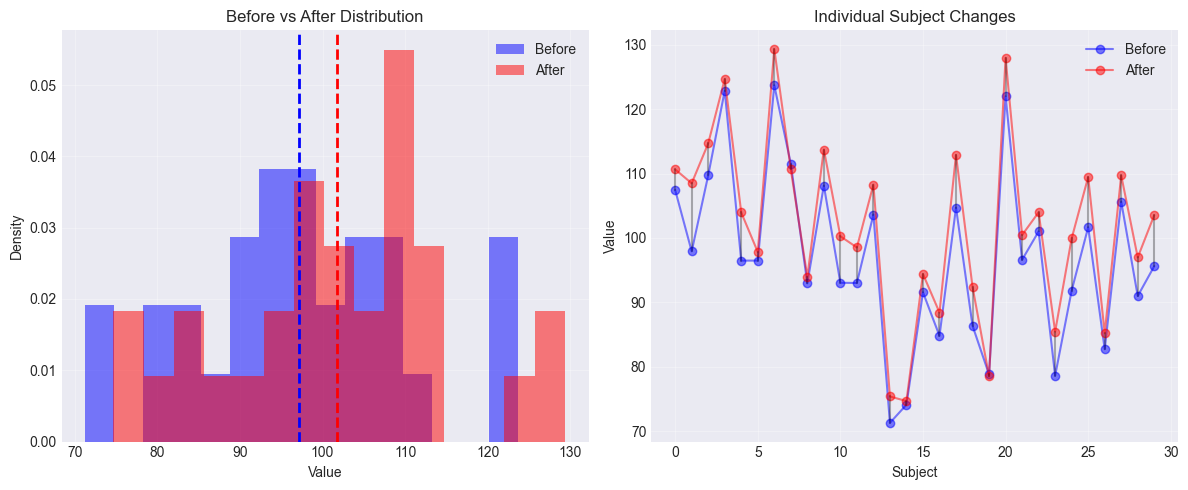

In [37]:
# Generate paired data (e.g., before and after treatment)
np.random.seed(42)
n_pairs = 30
before = np.random.normal(100, 15, n_pairs)
effect = np.random.normal(5, 3, n_pairs)  # Treatment effect
after = before + effect

# Paired t-test
t_stat, p_value = ttest_rel(before, after)

print("=" * 60)
print("PAIRED T-TEST (BEFORE-AFTER COMPARISON)")
print("=" * 60)
print(f"Before: Mean = {np.mean(before):.2f}, Std = {np.std(before):.2f}")
print(f"After: Mean = {np.mean(after):.2f}, Std = {np.std(after):.2f}")
print(f"Mean difference: {np.mean(after - before):.2f}")
print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Significant improvement: {p_value < 0.05}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before/after distributions
axes[0].hist(before, bins=15, alpha=0.5, label='Before', color='blue', density=True)
axes[0].hist(after, bins=15, alpha=0.5, label='After', color='red', density=True)
axes[0].axvline(np.mean(before), color='blue', linestyle='--', linewidth=2)
axes[0].axvline(np.mean(after), color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Density')
axes[0].set_title('Before vs After Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Individual changes
axes[1].plot(range(n_pairs), before, 'bo-', alpha=0.5, label='Before')
axes[1].plot(range(n_pairs), after, 'ro-', alpha=0.5, label='After')
for i in range(n_pairs):
    axes[1].plot([i, i], [before[i], after[i]], 'k-', alpha=0.3)
axes[1].set_xlabel('Subject')
axes[1].set_ylabel('Value')
axes[1].set_title('Individual Subject Changes')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 10. ANOVA (Analysis of Variance)

ONE-WAY ANOVA

Group Statistics:
Group A: Mean = 97.75, Std = 9.24
Group B: Mean = 105.18, Std = 8.66
Group C: Mean = 109.61, Std = 10.05
Group D: Mean = 102.84, Std = 8.85

F-statistic: 14.0792
p-value: 0.0000
Significant difference among groups: True

Tukey's HSD Post-hoc Test:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     A      B   7.4325 0.0005   2.6085 12.2566   True
     A      C  11.8619    0.0   7.0378 16.6859   True
     A      D   5.0937  0.034   0.2696  9.9178   True
     B      C   4.4293 0.0845  -0.3948  9.2534  False
     B      D  -2.3388 0.5918  -7.1629  2.4852  False
     C      D  -6.7682  0.002 -11.5922 -1.9441   True
-----------------------------------------------------


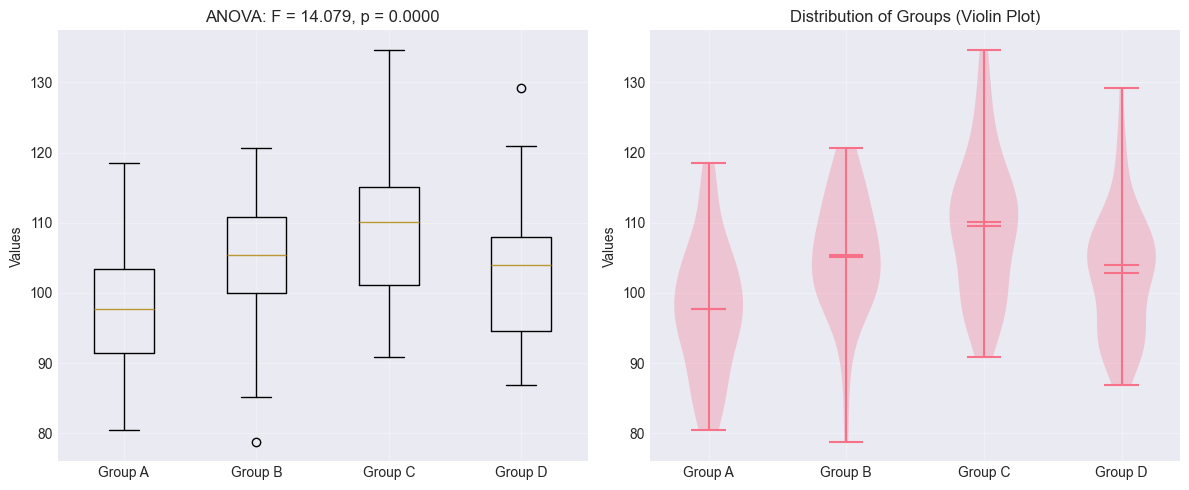

In [40]:
# Generate three or more groups
np.random.seed(42)
group_a = np.random.normal(100, 10, 50)
group_b = np.random.normal(105, 10, 50)
group_c = np.random.normal(110, 10, 50)
group_d = np.random.normal(102, 10, 50)

# Perform one-way ANOVA
f_stat, p_value = f_oneway(group_a, group_b, group_c, group_d)

print("=" * 60)
print("ONE-WAY ANOVA")
print("=" * 60)
print("\nGroup Statistics:")
print(f"Group A: Mean = {np.mean(group_a):.2f}, Std = {np.std(group_a):.2f}")
print(f"Group B: Mean = {np.mean(group_b):.2f}, Std = {np.std(group_b):.2f}")
print(f"Group C: Mean = {np.mean(group_c):.2f}, Std = {np.std(group_c):.2f}")
print(f"Group D: Mean = {np.mean(group_d):.2f}, Std = {np.std(group_d):.2f}")
print(f"\nF-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Significant difference among groups: {p_value < 0.05}")

# Post-hoc analysis (Tukey's HSD)
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Prepare data for Tukey test
all_data = np.concatenate([group_a, group_b, group_c, group_d])
group_labels = np.concatenate([['A']*50, ['B']*50, ['C']*50, ['D']*50])

tukey_result = pairwise_tukeyhsd(all_data, group_labels, alpha=0.05)

print("\nTukey's HSD Post-hoc Test:")
print(tukey_result)

# Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.boxplot([group_a, group_b, group_c, group_d], labels=['Group A', 'Group B', 'Group C', 'Group D'])
plt.ylabel('Values')
plt.title(f'ANOVA: F = {f_stat:.3f}, p = {p_value:.4f}')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Violin plot for better distribution visualization
data_to_plot = [group_a, group_b, group_c, group_d]
parts = plt.violinplot(data_to_plot, positions=[1,2,3,4], showmeans=True, showmedians=True)
plt.xticks([1,2,3,4], ['Group A', 'Group B', 'Group C', 'Group D'])
plt.ylabel('Values')
plt.title('Distribution of Groups (Violin Plot)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 11. Correlation Analysis

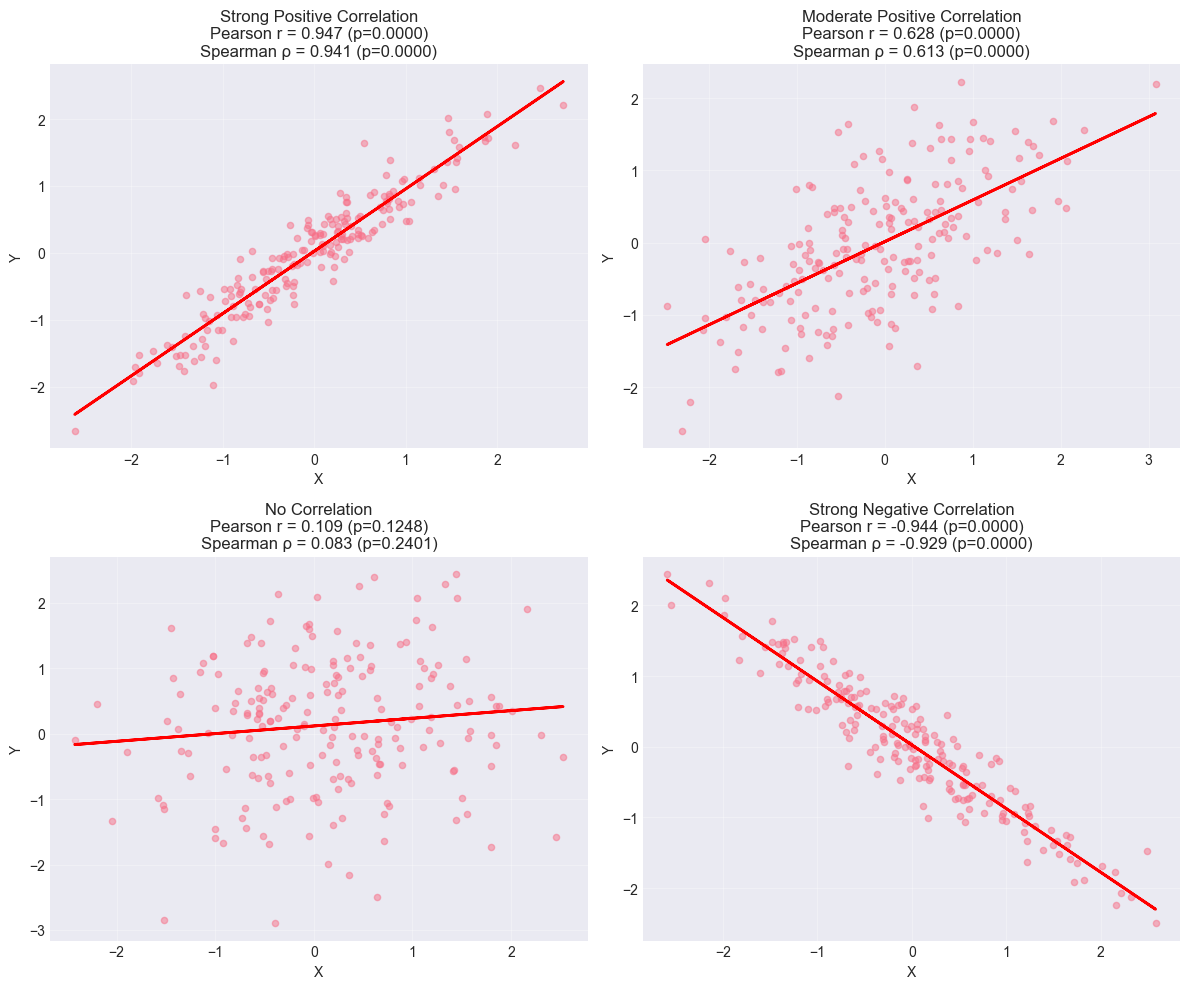

In [43]:
# Generate data with different correlation strengths
np.random.seed(42)
n = 200

# Different correlation scenarios
scenarios = {
    'Strong Positive Correlation': (0, 0.1),
    'Moderate Positive Correlation': (0, 0.5),
    'No Correlation': (0, 1.0),
    'Strong Negative Correlation': (0, -0.1)
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, (title, (mean, slope)) in enumerate(scenarios.items()):
    x = np.random.normal(0, 1, n)
    if title == 'Strong Negative Correlation':
        y = -0.9 * x + np.random.normal(0, 0.3, n)
    elif title == 'Strong Positive Correlation':
        y = 0.9 * x + np.random.normal(0, 0.3, n)
    elif title == 'Moderate Positive Correlation':
        y = 0.5 * x + np.random.normal(0, 0.7, n)
    else:
        y = np.random.normal(0, 1, n)
    
    # Calculate correlation coefficients
    pearson_r, pearson_p = pearsonr(x, y)
    spearman_r, spearman_p = spearmanr(x, y)
    
    # Scatter plot with regression line
    axes[idx].scatter(x, y, alpha=0.5, s=20)
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    axes[idx].plot(x, p(x), "r-", linewidth=2)
    
    axes[idx].set_title(f'{title}\nPearson r = {pearson_r:.3f} (p={pearson_p:.4f})\nSpearman ρ = {spearman_r:.3f} (p={spearman_p:.4f})')
    axes[idx].set_xlabel('X')
    axes[idx].set_ylabel('Y')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 12. Linear Regression

LINEAR REGRESSION RESULTS
True relationship: y = 2.50x + 5.00

Fitted relationship: y = 2.4310x + 5.3226
R-squared: 0.9661
Pearson correlation: 0.9829
p-value (slope ≠ 0): 7.3859e-74
Standard error of slope: 0.0460


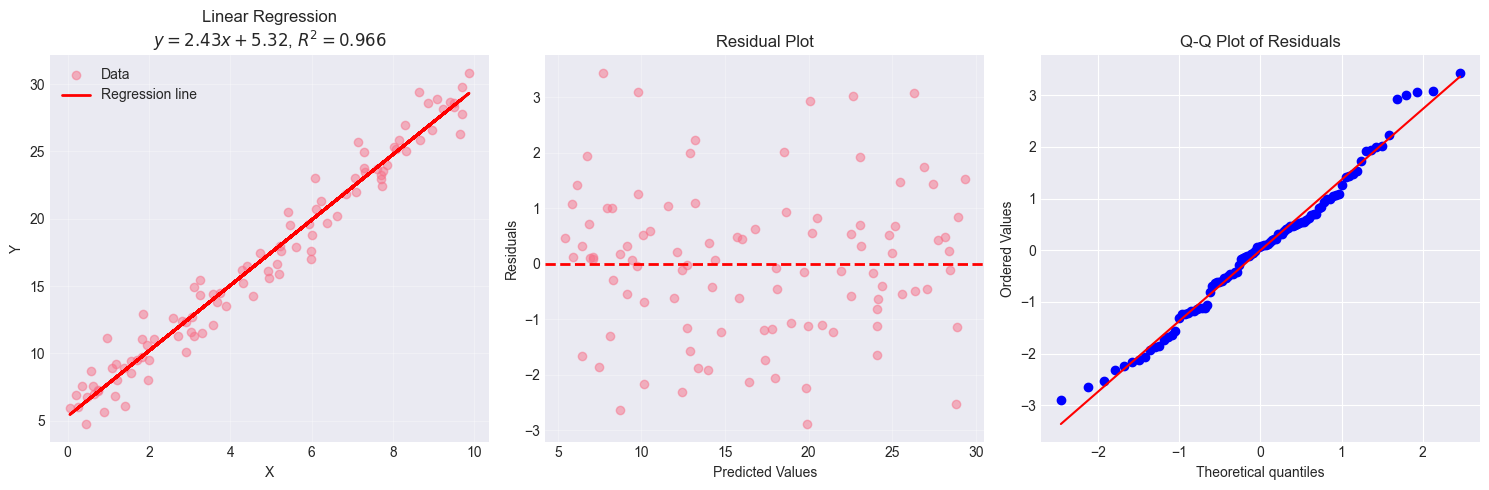


Regression Assumption Checks:
Normality of residuals (Shapiro-Wilk): p = 0.2984
Constant variance (visual check of residual plot)


In [46]:
# Generate data with linear relationship
np.random.seed(42)
X = np.random.uniform(0, 10, 100)
true_slope = 2.5
true_intercept = 5.0
noise = np.random.normal(0, 1.5, 100)
y = true_slope * X + true_intercept + noise

# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(X, y)

# Calculate predictions and residuals
y_pred = slope * X + intercept
residuals = y - y_pred

print("=" * 60)
print("LINEAR REGRESSION RESULTS")
print("=" * 60)
print(f"True relationship: y = {true_slope:.2f}x + {true_intercept:.2f}")
print(f"\nFitted relationship: y = {slope:.4f}x + {intercept:.4f}")
print(f"R-squared: {r_value**2:.4f}")
print(f"Pearson correlation: {r_value:.4f}")
print(f"p-value (slope ≠ 0): {p_value:.4e}")
print(f"Standard error of slope: {std_err:.4f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Regression plot
axes[0].scatter(X, y, alpha=0.5, label='Data')
axes[0].plot(X, y_pred, 'r-', linewidth=2, label='Regression line')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].set_title(f'Linear Regression\n$y = {slope:.2f}x + {intercept:.2f}$, $R^2 = {r_value**2:.3f}$')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Residuals plot
axes[1].scatter(y_pred, residuals, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

# 3. Q-Q plot of residuals
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

# Check assumptions
print("\nRegression Assumption Checks:")
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"Normality of residuals (Shapiro-Wilk): p = {shapiro_p:.4f}")
print(f"Constant variance (visual check of residual plot)")

# 13. Chi-Square Test for Independence

CHI-SQUARE TEST FOR INDEPENDENCE

Contingency Table:
Product    A   B   C
Gender              
Female   105  91  60
Male     100  77  67

Chi-square statistic: 1.3872
p-value: 0.4998
Degrees of freedom: 2

Expected frequencies (if independent):
Product        A       B       C
Gender                          
Female  104.9600 86.0160 65.0240
Male    100.0400 81.9840 61.9760

Conclusion: Variables are independent (α=0.05)
Cramer's V (effect size): 0.0527


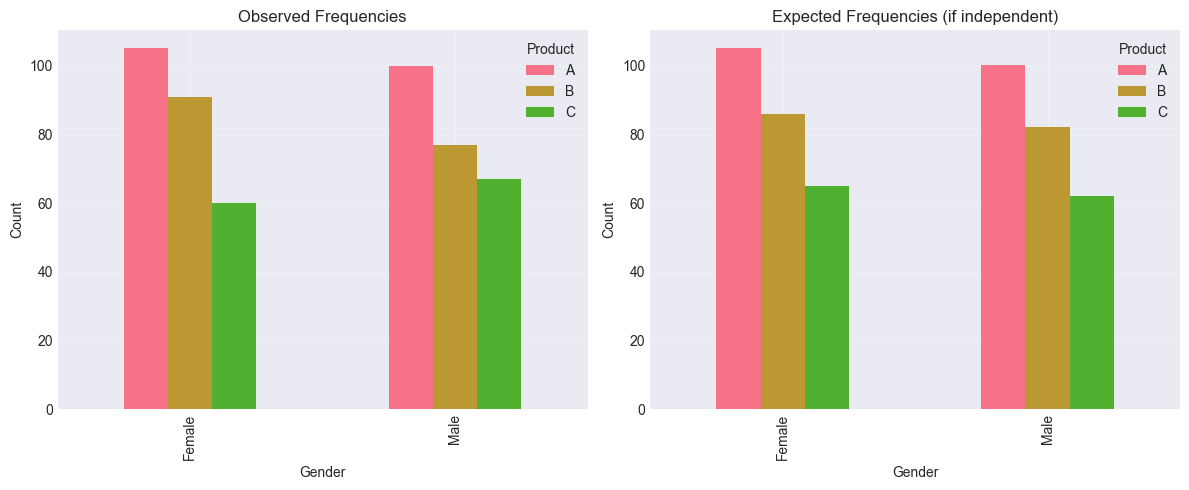

In [51]:
# Create contingency table (e.g., survey data)
from scipy.stats import chi2_contingency
np.random.seed(42)
n_respondents = 500

# Simulate survey: Gender vs Product Preference
survey_data = pd.DataFrame({
    'Gender': np.random.choice(['Male', 'Female'], n_respondents),
    'Product': np.random.choice(['A', 'B', 'C'], n_respondents, p=[0.4, 0.35, 0.25])
})

# Create contingency table
contingency_table = pd.crosstab(survey_data['Gender'], survey_data['Product'])
print("=" * 60)
print("CHI-SQUARE TEST FOR INDEPENDENCE")
print("=" * 60)
print("\nContingency Table:")
print(contingency_table)

# Perform Chi-Square test
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-square statistic: {chi2_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")
print("\nExpected frequencies (if independent):")
expected_df = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)
print(expected_df)
print(f"\nConclusion: Variables are {'dependent' if p_value < 0.05 else 'independent'} (α=0.05)")

# Calculate Cramer's V (effect size)
n_total = contingency_table.sum().sum()
min_dim = min(contingency_table.shape) - 1
cramers_v = np.sqrt(chi2_stat / (n_total * min_dim))
print(f"Cramer's V (effect size): {cramers_v:.4f}")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Observed frequencies
contingency_table.plot(kind='bar', ax=ax1)
ax1.set_title('Observed Frequencies')
ax1.set_ylabel('Count')
ax1.legend(title='Product')
ax1.grid(True, alpha=0.3)

# Expected frequencies
expected_df.plot(kind='bar', ax=ax2)
ax2.set_title('Expected Frequencies (if independent)')
ax2.set_ylabel('Count')
ax2.legend(title='Product')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 14. Non-Parametric Statistics

NON-PARAMETRIC STATISTICS

1. Mann-Whitney U Test (Independent Samples):
Group 1 median: 1.25
Group 2 median: 2.11
Parametric t-test p-value: 0.0010
Non-parametric U-test p-value: 0.0023

2. Wilcoxon Signed-Rank Test (Paired Samples):
Before median: 103.87
After median: 105.97
p-value: 0.0000

3. Kruskal-Wallis H-test (Non-parametric ANOVA):
Group medians: 1.28, 2.30, 1.97
H-statistic: 5.6570
p-value: 0.0591


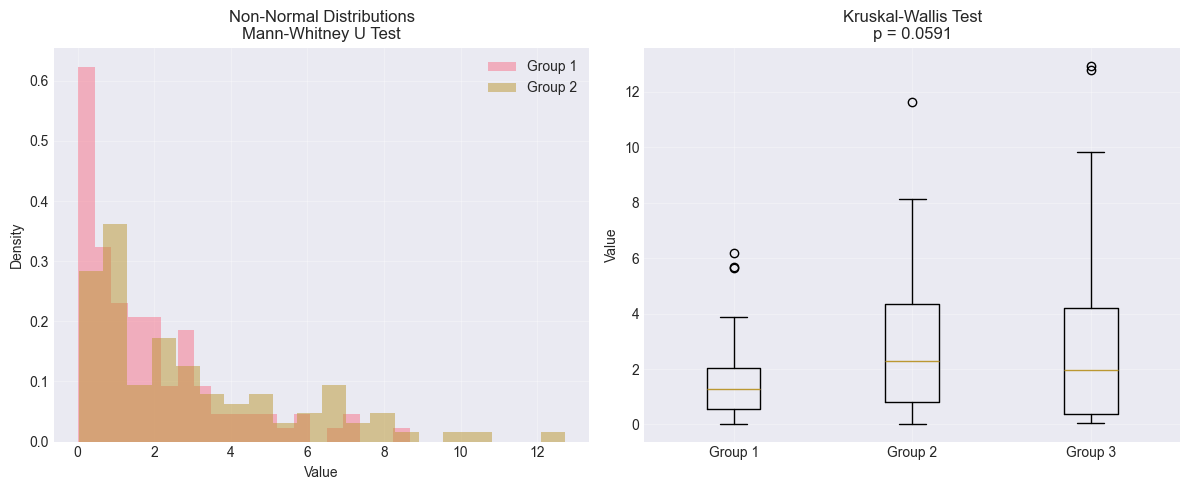

In [54]:
# Generate non-normal data for non-parametric test comparison
np.random.seed(42)

# Create two skewed distributions
group1_nonparam = np.random.exponential(2, 100)
group2_nonparam = np.random.exponential(3, 100)

# Parametric test (t-test) - may violate normality assumption
t_stat, p_t = ttest_ind(group1_nonparam, group2_nonparam)

# Non-parametric test (Mann-Whitney U)
u_stat, p_u = mannwhitneyu(group1_nonparam, group2_nonparam)

# Additional non-parametric tests
# Wilcoxon signed-rank test (paired)
before_paired = np.random.normal(100, 20, 50)
after_paired = before_paired + np.random.exponential(2, 50)
wilcoxon_stat, wilcoxon_p = stats.wilcoxon(before_paired, after_paired)

# Kruskal-Wallis H-test (non-parametric ANOVA)
group1_kw = np.random.exponential(2, 50)
group2_kw = np.random.exponential(2.5, 50)
group3_kw = np.random.exponential(3, 50)
h_stat, p_kw = kruskal(group1_kw, group2_kw, group3_kw)

print("=" * 60)
print("NON-PARAMETRIC STATISTICS")
print("=" * 60)

print("\n1. Mann-Whitney U Test (Independent Samples):")
print(f"Group 1 median: {np.median(group1_nonparam):.2f}")
print(f"Group 2 median: {np.median(group2_nonparam):.2f}")
print(f"Parametric t-test p-value: {p_t:.4f}")
print(f"Non-parametric U-test p-value: {p_u:.4f}")

print("\n2. Wilcoxon Signed-Rank Test (Paired Samples):")
print(f"Before median: {np.median(before_paired):.2f}")
print(f"After median: {np.median(after_paired):.2f}")
print(f"p-value: {wilcoxon_p:.4f}")

print("\n3. Kruskal-Wallis H-test (Non-parametric ANOVA):")
print(f"Group medians: {np.median(group1_kw):.2f}, {np.median(group2_kw):.2f}, {np.median(group3_kw):.2f}")
print(f"H-statistic: {h_stat:.4f}")
print(f"p-value: {p_kw:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Distributions
axes[0].hist(group1_nonparam, bins=20, alpha=0.5, label='Group 1', density=True)
axes[0].hist(group2_nonparam, bins=20, alpha=0.5, label='Group 2', density=True)
axes[0].set_title('Non-Normal Distributions\nMann-Whitney U Test')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot for Kruskal-Wallis
axes[1].boxplot([group1_kw, group2_kw, group3_kw], labels=['Group 1', 'Group 2', 'Group 3'])
axes[1].set_title(f'Kruskal-Wallis Test\np = {p_kw:.4f}')
axes[1].set_ylabel('Value')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 15. Power Analysis and Sample Size Determination

POWER ANALYSIS

Required sample size per group (α=0.05, power=0.8):
Effect size 0.2: n = 394 subjects per group
Effect size 0.5: n = 64 subjects per group
Effect size 0.8: n = 26 subjects per group


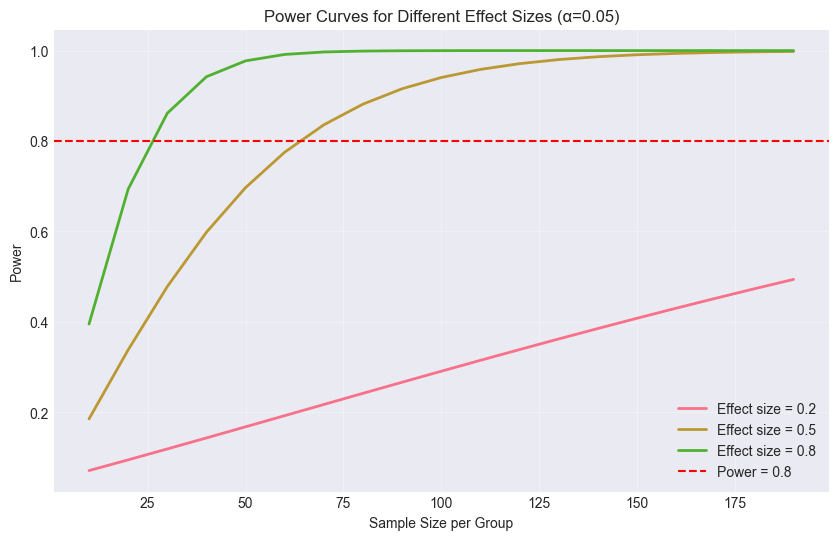


Cohen's d Effect Size Interpretation:
d = 0.2: Small effect
d = 0.5: Medium effect
d = 0.8: Large effect


In [57]:
from statsmodels.stats.power import TTestIndPower, TTestPower

# Power analysis for t-test
effect_sizes = [0.2, 0.5, 0.8]  # small, medium, large
alpha = 0.05
power = 0.8

print("=" * 60)
print("POWER ANALYSIS")
print("=" * 60)

# Calculate required sample sizes
analysis = TTestIndPower()
print("\nRequired sample size per group (α=0.05, power=0.8):")
for effect in effect_sizes:
    n = analysis.solve_power(effect_size=effect, alpha=alpha, power=power, alternative='two-sided')
    print(f"Effect size {effect}: n = {np.ceil(n):.0f} subjects per group")

# Power curves
plt.figure(figsize=(10, 6))
sample_sizes = np.arange(10, 200, 10)
for effect in effect_sizes:
    powers = [analysis.power(effect_size=effect, nobs1=n, alpha=alpha) for n in sample_sizes]
    plt.plot(sample_sizes, powers, label=f'Effect size = {effect}', linewidth=2)

plt.axhline(y=0.8, color='r', linestyle='--', label='Power = 0.8')
plt.xlabel('Sample Size per Group')
plt.ylabel('Power')
plt.title('Power Curves for Different Effect Sizes (α=0.05)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Effect size interpretation
print("\nCohen's d Effect Size Interpretation:")
print("d = 0.2: Small effect")
print("d = 0.5: Medium effect")
print("d = 0.8: Large effect")

# 16. Practical Case Study: Comparing Teaching Methods

CASE STUDY: COMPARING TEACHING METHODS

Descriptive Statistics by Method:
              count    mean    std     min     25%     50%     75%      max
Method                                                                     
Blended     40.0000 85.1017 8.6209 65.8123 80.5908 84.6939 88.3584 109.6324
Online      40.0000 79.7096 9.6477 53.8025 74.7934 80.2561 87.5698  95.6464
Traditional 40.0000 72.8136 9.5281 55.4033 65.6577 72.6585 78.2961  93.5228

One-way ANOVA Results:
F-statistic: 17.6330
p-value: 0.0000
Significant difference: True
Effect size (η²): 0.2316

Tukey HSD Post-hoc Comparison:
    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
 group1    group2   meandiff p-adj   lower    upper  reject
-----------------------------------------------------------
Blended      Online  -5.3922 0.0282 -10.3166 -0.4678   True
Blended Traditional -12.2881    0.0 -17.2125 -7.3637   True
 Online Traditional  -6.8959 0.0034 -11.8203 -1.9715   True
---------------------------------------

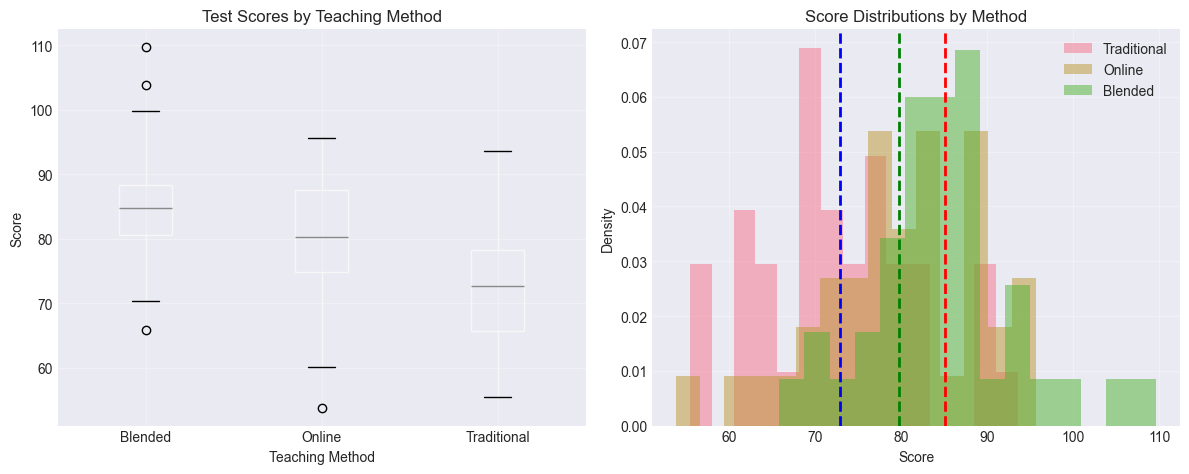


CONCLUSIONS AND RECOMMENDATIONS
✓ There is a statistically significant difference between teaching methods
✓ The Blended method shows the highest average scores
✓ Large effect size detected - the difference is practically significant

Recommendation: Consider adopting the Blended learning approach


In [60]:
# Real-world case study: Comparing effectiveness of three teaching methods
np.random.seed(42)

# Generate data for three teaching methods
method_names = ['Traditional', 'Online', 'Blended']
n_students = 40

# Different means for each method
method_a = np.random.normal(75, 10, n_students)  # Traditional
method_b = np.random.normal(80, 10, n_students)  # Online
method_c = np.random.normal(85, 10, n_students)  # Blended

# Combine data
scores = np.concatenate([method_a, method_b, method_c])
methods = np.repeat(method_names, n_students)

# Create DataFrame
df_study = pd.DataFrame({'Method': methods, 'Score': scores})

print("=" * 60)
print("CASE STUDY: COMPARING TEACHING METHODS")
print("=" * 60)

# Descriptive statistics
print("\nDescriptive Statistics by Method:")
print(df_study.groupby('Method')['Score'].describe())

# ANOVA
f_stat, p_value = f_oneway(method_a, method_b, method_c)
print(f"\nOne-way ANOVA Results:")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Significant difference: {p_value < 0.05}")

# Effect size (Eta-squared)
ss_between = (len(method_a)*(np.mean(method_a)-np.mean(scores))**2 +
              len(method_b)*(np.mean(method_b)-np.mean(scores))**2 +
              len(method_c)*(np.mean(method_c)-np.mean(scores))**2)
ss_total = np.sum((scores - np.mean(scores))**2)
eta_squared = ss_between / ss_total
print(f"Effect size (η²): {eta_squared:.4f}")

# Post-hoc tests
tukey = pairwise_tukeyhsd(scores, methods, alpha=0.05)
print("\nTukey HSD Post-hoc Comparison:")
print(tukey)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box plot
df_study.boxplot(column='Score', by='Method', ax=axes[0])
axes[0].set_title('Test Scores by Teaching Method')
axes[0].set_ylabel('Score')
axes[0].set_xlabel('Teaching Method')
axes[0].grid(True, alpha=0.3)

# Histogram with KDE
for method, color in zip(method_names, ['blue', 'green', 'red']):
    subset = df_study[df_study['Method'] == method]['Score']
    axes[1].hist(subset, bins=15, alpha=0.5, label=method, density=True)
    axes[1].axvline(subset.mean(), color=color, linestyle='--', linewidth=2)

axes[1].set_title('Score Distributions by Method')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('')  # Remove automatic title
plt.tight_layout()
plt.show()

# Recommendations
print("\n" + "=" * 60)
print("CONCLUSIONS AND RECOMMENDATIONS")
print("=" * 60)
if p_value < 0.05:
    print("✓ There is a statistically significant difference between teaching methods")
    print("✓ The Blended method shows the highest average scores")
    if eta_squared > 0.14:
        print("✓ Large effect size detected - the difference is practically significant")
    print("\nRecommendation: Consider adopting the Blended learning approach")
else:
    print("✗ No statistically significant difference found between methods")
    print("✗ Consider larger sample size or different experimental design")

# 17. Summary and Best Practices

In [63]:
# Create a summary table of statistical tests
summary_stats = pd.DataFrame({
    'Test': [
        'One-sample t-test', 'Independent t-test', 'Paired t-test', 
        'ANOVA', 'Mann-Whitney U', 'Wilcoxon', 'Kruskal-Wallis',
        'Pearson correlation', 'Spearman correlation', 'Chi-square'
    ],
    'Purpose': [
        'Compare sample mean to population mean',
        'Compare means of two independent groups',
        'Compare means of two related groups',
        'Compare means of three or more groups',
        'Compare medians of two independent groups (non-parametric)',
        'Compare medians of two related groups (non-parametric)',
        'Compare medians of three+ groups (non-parametric)',
        'Measure linear relationship between variables',
        'Measure monotonic relationship (non-parametric)',
        'Test independence of categorical variables'
    ],
    'Assumptions': [
        'Normality', 'Normality, equal variance', 'Normality of differences',
        'Normality, homogeneity of variance', 'None (non-parametric)',
        'None (non-parametric)', 'None (non-parametric)',
        'Linearity, normality', 'None (non-parametric)', 'Expected frequency > 5'
    ]
})

print("=" * 80)
print("QUICK REFERENCE: STATISTICAL TESTS")
print("=" * 80)
print(summary_stats.to_string(index=False))

print("\n" + "=" * 80)
print("BEST PRACTICES IN STATISTICS")
print("=" * 80)

best_practices = """
1. ALWAYS visualize your data before statistical testing
2. Check assumptions of statistical tests (normality, homogeneity of variance)
3. Report effect sizes alongside p-values
4. Use appropriate multiple comparison corrections when needed
5. Consider sample size and power before conducting studies
6. Distinguish between statistical significance and practical significance
7. Report confidence intervals for estimates
8. Use non-parametric tests when assumptions are violated
9. Avoid p-hacking and HARKing (Hypothesizing After Results are Known)
10. Reproducibility: Share code and document analysis steps

Common Pitfalls to Avoid:
- Using parametric tests on non-normal data without transformation
- Ignoring multiple comparison issues
- Confusing correlation with causation
- Over-interpreting non-significant results
- Using inappropriate post-hoc tests
- Not checking for outliers
"""

print(best_practices)

QUICK REFERENCE: STATISTICAL TESTS
                Test                                                    Purpose                        Assumptions
   One-sample t-test                     Compare sample mean to population mean                          Normality
  Independent t-test                    Compare means of two independent groups          Normality, equal variance
       Paired t-test                        Compare means of two related groups           Normality of differences
               ANOVA                      Compare means of three or more groups Normality, homogeneity of variance
      Mann-Whitney U Compare medians of two independent groups (non-parametric)              None (non-parametric)
            Wilcoxon     Compare medians of two related groups (non-parametric)              None (non-parametric)
      Kruskal-Wallis          Compare medians of three+ groups (non-parametric)              None (non-parametric)
 Pearson correlation              Measure lin

# 18. Additional Resources

In [66]:
resources = {
    'Books': [
        '"Statistics" by Freedman, Pisani, Purves',
        '"The Elements of Statistical Learning" by Hastie et al.',
        '"Practical Statistics for Data Scientists" by Bruce & Bruce'
    ],
    'Online Courses': [
        'Coursera: Statistics with R/Python Specialization',
        'edX: Harvard\'s Data Science Professional Certificate',
        'Khan Academy: Statistics and probability'
    ],
    'Python Libraries': [
        'scipy.stats - Core statistical functions',
        'statsmodels - Statistical modeling and tests',
        'pingouin - Easy statistical testing',
        'PyMC3 - Bayesian statistics'
    ],
    'Visualization': [
        'seaborn - Statistical data visualization',
        'matplotlib - Basic plotting',
        'plotly - Interactive statistics'
    ]
}

print("=" * 80)
print("ADDITIONAL RESOURCES FOR LEARNING STATISTICS")
print("=" * 80)

for category, items in resources.items():
    print(f"\n{category}:")
    for item in items:
        print(f"  • {item}")

ADDITIONAL RESOURCES FOR LEARNING STATISTICS

Books:
  • "Statistics" by Freedman, Pisani, Purves
  • "The Elements of Statistical Learning" by Hastie et al.
  • "Practical Statistics for Data Scientists" by Bruce & Bruce

Online Courses:
  • Coursera: Statistics with R/Python Specialization
  • edX: Harvard's Data Science Professional Certificate
  • Khan Academy: Statistics and probability

Python Libraries:
  • scipy.stats - Core statistical functions
  • statsmodels - Statistical modeling and tests
  • pingouin - Easy statistical testing
  • PyMC3 - Bayesian statistics

Visualization:
  • seaborn - Statistical data visualization
  • matplotlib - Basic plotting
  • plotly - Interactive statistics


# 19. Practice Exercises

In [69]:
print("=" * 80)
print("PRACTICE EXERCISES")
print("=" * 80)

exercises = """
Exercise 1: Central Tendency and Dispersion
-------------------------------------------
Given the dataset: [12, 15, 14, 18, 22, 19, 21, 20, 23, 25]
Calculate mean, median, mode, variance, and standard deviation.
Check if the data follows a normal distribution.

Exercise 2: Hypothesis Testing
------------------------------
A company claims their light bulbs last 1000 hours on average.
You test 30 bulbs and find a mean of 980 hours with std of 50 hours.
Test the company's claim at α=0.05 significance level.

Exercise 3: Correlation
-----------------------
Study the relationship between hours studied (X) and exam scores (Y):
X: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Y: [55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
Calculate Pearson correlation and perform linear regression.

Exercise 4: ANOVA
----------------
Three different diets were tested for weight loss:
Diet A: [2, 3, 4, 5, 4, 3, 4, 5]
Diet B: [4, 5, 6, 5, 7, 6, 5, 6]
Diet C: [6, 7, 8, 7, 9, 8, 7, 8]
Determine if there's a significant difference between diets.

Exercise 5: Chi-Square Test
---------------------------
Survey of 200 people: 120 prefer Coke, 80 prefer Pepsi.
Test if preference is equally distributed (50-50) at α=0.05.

Bonus Exercise: Power Analysis
-----------------------------
You want to detect a medium effect size (d=0.5) with 80% power at α=0.05.
Calculate the required sample size for a two-sample t-test.
"""

print(exercises)

print("\n" + "=" * 80)
print("Solutions to exercises can be found in the next code cell")
print("=" * 80)

PRACTICE EXERCISES

Exercise 1: Central Tendency and Dispersion
-------------------------------------------
Given the dataset: [12, 15, 14, 18, 22, 19, 21, 20, 23, 25]
Calculate mean, median, mode, variance, and standard deviation.
Check if the data follows a normal distribution.

Exercise 2: Hypothesis Testing
------------------------------
A company claims their light bulbs last 1000 hours on average.
You test 30 bulbs and find a mean of 980 hours with std of 50 hours.
Test the company's claim at α=0.05 significance level.

Exercise 3: Correlation
-----------------------
Study the relationship between hours studied (X) and exam scores (Y):
X: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Y: [55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
Calculate Pearson correlation and perform linear regression.

Exercise 4: ANOVA
----------------
Three different diets were tested for weight loss:
Diet A: [2, 3, 4, 5, 4, 3, 4, 5]
Diet B: [4, 5, 6, 5, 7, 6, 5, 6]
Diet C: [6, 7, 8, 7, 9, 8, 7, 8]
Determine if there's a 

In [71]:
# Solutions to exercises (uncomment to check your answers)

"""
# Exercise 1 Solutions
data = [12, 15, 14, 18, 22, 19, 21, 20, 23, 25]
print(f"Mean: {np.mean(data)}")
print(f"Median: {np.median(data)}")
print(f"Std: {np.std(data)}")

# Exercise 2 Solutions
t_stat, p_value = ttest_1samp([980]*30, 1000)
print(f"t-statistic: {t_stat}, p-value: {p_value}")

# Exercise 3 Solutions
X = [1,2,3,4,5,6,7,8,9,10]
Y = [55,60,65,70,75,80,85,90,95,100]
corr, p = pearsonr(X, Y)
print(f"Correlation: {corr}, p-value: {p}")

# Exercise 4 Solutions
diet_a = [2,3,4,5,4,3,4,5]
diet_b = [4,5,6,5,7,6,5,6]
diet_c = [6,7,8,7,9,8,7,8]
f_stat, p_value = f_oneway(diet_a, diet_b, diet_c)
print(f"F-statistic: {f_stat}, p-value: {p_value}")

# Exercise 5 Solutions
observed = [120, 80]
expected = [100, 100]
chi2_stat, p_value = stats.chisquare(observed, expected)
print(f"Chi-square: {chi2_stat}, p-value: {p_value}")
"""

print("\n" + "=" * 80)
print("🎉 TUTORIAL COMPLETE! 🎉")
print("Practice these concepts with real datasets to master statistics!")
print("=" * 80)


🎉 TUTORIAL COMPLETE! 🎉
Practice these concepts with real datasets to master statistics!
